# NN Concept
The network tried to learn good embeddings for each node:
- NodeTypeEmbedder embedded nodes regardless of fanins and fanouts.
- ExpAIG_RNN (not a RNN actually) traversed the AIG graph bottom up to calculate the complete embeddings of each node.
- ValuePredictor predicted N-boolean outputs of the node, given node's complete embedding and N-instances each of M input variables.

Results:
- ExpAIG_RNN seemed to create close embeddings for output nodes of same operation's circuit, but PCA showed that embeddings were one-dimensional and model learnt almost same embedding for all nodes.
- ValuePredictor learnt **nothing**. 

In [ ]:
import torch
from torch import nn, Tensor
import torch.nn.functional as F

import matplotlib.pyplot as plt
import random

from aig_grapher import AIG
from setup import aag_path

device = "cuda" if torch.cuda.is_available() else "cpu"

In [48]:
from typing import Dict, List
from typing import Any

EMBEDDING_SIZE = 128


class VecNormalize(nn.Module):
	def __init__(self):
		super().__init__()

	def forward(self, x: torch.Tensor):
		return F.normalize(x, p=2, dim=1)


class NodeTypeEmbedder(nn.Module):
	def __init__(self):
		super().__init__()

		self.emb = nn.Sequential(
			nn.Linear(2, 32), nn.ReLU(), nn.Linear(32, EMBEDDING_SIZE), nn.ReLU(),
			VecNormalize()
		)

	def forward(self, x: Tensor):
		return self.emb(x)

class Attention(nn.Module):
	def __init__(self, emb_size: int, instances: int):
		super().__init__()
		self.q_mappers = nn.ModuleList([nn.Linear(emb_size, emb_size) for _ in range(instances)])

	def forward(self, Q:Tensor, k: Tensor, V: Tensor) -> Tensor:
		k = k.squeeze(1)
		# print("qkv:", Q.shape, k.shape, V.shape)
		algns: List[Tensor] = []
		for mapper in self.q_mappers:
			mp = F.relu(mapper(Q))

			algn = torch.matmul(mp, k.T)
			algn = VecNormalize()(algn)
			algns.append(algn)
		
		algnsT = torch.cat(algns, dim=1)
		out = torch.matmul(algnsT, V)
		# print("out:", out.shape)
		return out

class ValuePredictor(nn.Module):
	def __init__(self, input_bits: int, n_instances: int=3):
		super().__init__()

		self.attn = Attention(EMBEDDING_SIZE, n_instances)
		self.map = nn.Sequential(
			nn.Linear(n_instances, 32),
			nn.ReLU(),
			nn.Linear(32, 32),
			nn.ReLU(),
			nn.Linear(32, 1),
		)

	def forward(self, node_emb: Tensor, input_embs: Tensor, inputs: Tensor):
		attn_val: Tensor = self.attn(node_emb, input_embs, inputs) # shape: [batch, attn_heads, sim_bitsz]
		attn_val = attn_val.transpose(1, 2) # shape: [batch, sim_bitsz, attn_heads]
		out = self.map(attn_val).squeeze(2)
		return F.sigmoid(out)


# Add node type embedding like BullsEye does

class ExpAIG_RNN(nn.Module):
	def __init__(self):
		super().__init__()

		self.inv_model = nn.Sequential(
			nn.Linear(EMBEDDING_SIZE, EMBEDDING_SIZE),
			nn.ReLU(),
			nn.Linear(EMBEDDING_SIZE, EMBEDDING_SIZE),
			nn.ReLU(),
			VecNormalize(),
		)

		self.and_model = nn.Sequential(
			nn.Linear(3 * EMBEDDING_SIZE, 2 * EMBEDDING_SIZE),
			nn.ReLU(),
			nn.Linear(2 * EMBEDDING_SIZE, EMBEDDING_SIZE),
			nn.ReLU(),
			VecNormalize(),
		)

	def forward(self, x: AIG, node_values: Dict[int, Tensor], int_node_embed: Tensor):		
		# Only intermediate nodes will have their values assigned here
		# TODO add value_pred calculation here
		node_values, output_values = x.generalized_sim(
			node_values=node_values,
			inv_fn=lambda x: self.inv_model(x),
			and_fn=lambda xy: self.and_model(
				torch.cat((int_node_embed, torch.cat(xy, dim=1)), dim=1)
			),
		)

		return node_values, output_values
		

In [49]:
BIT_SIZE = 6
beh_mult = AIG(aag_path/f"behavioral_mult_{BIT_SIZE}bit.aag")
unr_mult = AIG(aag_path/f"unrolled_mult_{BIT_SIZE}bit.aag")

In [52]:
model = ExpAIG_RNN().to(device)

inp_ohe = torch.Tensor([[1, 0]]).to(device)
int_ohe = torch.Tensor([[0, 1]]).to(device)

base_emb_model = NodeTypeEmbedder().to(device)
val_predr = ValuePredictor(128).to(device)

opt = torch.optim.SGD(
    list(model.parameters()) + list(base_emb_model.parameters()) + list(val_predr.parameters()),
    lr=5e-1
)

In [53]:
from typing import Tuple

output_embedding_loss = nn.CosineEmbeddingLoss()
boolean_matching_loss = nn.BCELoss()

losses: List[Any] = []
for s in range(5):
	print("\n========= Running new simulation =========\n")

	input_bitsz = 128
	input_vals = {i: [random.randint(0, 1) for _ in range(input_bitsz)] for i in beh_mult.input_ids}
	input_vals.update({0: [0 for _ in range(input_bitsz)]})

	input_binary: List[List[int]] = []
	for k in beh_mult.input_ids:
		input_binary.append(input_vals[k])
	input_binaryT = Tensor(input_binary).to(device)

	beh_node_values, _ = beh_mult.generalized_sim(
		input_vals.copy(),
		lambda x: [1 - v for v in x],
		lambda xy: [1 if bool(xy[0][i]) and bool(xy[1][i]) else 0 for i in range(len(xy[0]))]
	)

	unr_node_values, _ = unr_mult.generalized_sim(
		input_vals.copy(),
		lambda x: [1 - v for v in x],
		lambda xy: [bool(xy[0][i]) and bool(xy[1][i]) for i in range(len(xy[0]))]
	)

	for it in range(50):
		inp_emb: Tensor = base_emb_model(inp_ohe)

		# NOTE Training assumes that input and output ids are matched
		node_values = {
			i: inp_emb + torch.sin(torch.Tensor([i]).to(device) / 1000) for i in beh_mult.input_ids
		}
		node_values.update({0: inp_emb + torch.sin(torch.Tensor([0]).to(device) / 1000)})
		int_node_embed = base_emb_model(int_ohe)

		# Calculate all embeddings using the embedding network
		def calculate_embeddings(aig: AIG) -> Tuple[Dict[int, Tensor], Tensor]:
			embs, outs = model(aig, node_values.copy(), int_node_embed)
			outs = torch.cat(outs, dim=0)
			return embs, outs
		
		beh_embs, beh_out = calculate_embeddings(beh_mult)
		unr_embs, unr_out = calculate_embeddings(unr_mult)
		
		# Calculating output embedding loss
		target = torch.ones((beh_out.shape[0])).to(device)
		oe_loss = output_embedding_loss(beh_out, unr_out, target)

		# Calculating boolean matching loss
		def get_all_embeddings_and_exp_outs(embs_map: Dict[int, Tensor], outs_map: Dict[int, list[int]], device: str):
			embs: List[Tensor] = []
			outs: List[Tensor] = []

			for id in embs_map.keys():
				embs.append(embs_map[id])
				outs.append(torch.Tensor(outs_map[id]).to(device))

			embsT = torch.stack(embs, dim=0)
			outsT = torch.stack(outs, dim=0)

			return embsT, outsT
		
		def get_inputs_tensor(device: str):
			return torch.stack([node_values[i] for i in beh_mult.input_ids], dim=0).to(device)

		inputsT = get_inputs_tensor(device)
		embs: List[Tensor] = []
		outs: List[Tensor] = []
		for aig in [beh_mult, unr_mult]:
			emb, out = get_all_embeddings_and_exp_outs(beh_embs, beh_node_values, device)
			embs.append(emb)
			outs.append(out)

		# TODO TODO possible to parallelize both circuits together because Predictor is not sequential
		embsT = torch.cat(embs, dim=0).to(device)
		outsT = torch.cat(outs, dim=0).to(device)
		preds = val_predr(embsT, inputsT, input_binaryT)
		
		bm_loss = boolean_matching_loss(preds, outsT)
		loss = 10 * bm_loss + oe_loss

		opt.zero_grad()
		loss.backward()
		opt.step()

		losses.append(loss.item())
		print(f"Loss at iteration {it}: {loss.item()} | BM_Loss: {bm_loss.item()} | OE_Loss: {oe_loss.item()}")
	
plt.plot(losses)


========= Running new simulation =========



Loss at iteration 0: 6.9482316970825195 | BM_Loss: 0.6327096223831177 | OE_Loss: 0.6211355924606323
Loss at iteration 1: 6.9262895584106445 | BM_Loss: 0.6323218941688538 | OE_Loss: 0.6030706167221069
Loss at iteration 2: 7.261852264404297 | BM_Loss: 0.6963876485824585 | OE_Loss: 0.29797548055648804
Loss at iteration 3: 25.419986724853516 | BM_Loss: 2.5285329818725586 | OE_Loss: 0.13465654850006104
Loss at iteration 4: 9.671967506408691 | BM_Loss: 0.9613828659057617 | OE_Loss: 0.05813923478126526
Loss at iteration 5: 9.207901954650879 | BM_Loss: 0.9183759689331055 | OE_Loss: 0.024142324924468994
Loss at iteration 6: 7.61680793762207 | BM_Loss: 0.7606989145278931 | OE_Loss: 0.009819075465202332
Loss at iteration 7: 6.549259662628174 | BM_Loss: 0.6545277237892151 | OE_Loss: 0.003982653375715017
Loss at iteration 8: 6.264704704284668 | BM_Loss: 0.6263095736503601 | OE_Loss: 0.0016087989788502455
Loss at iteration 9: 6.263494968414307 | BM_Loss: 0.6262848377227783 | OE_Loss: 0.0006464074249

KeyboardInterrupt: 

In [ ]:
from sklearn.decomposition import PCA
def get_pca_out(aig: AIG):
	node_values = {
		i: inp_emb + torch.sin(torch.Tensor([i]).to(device) / 1000) for i in aig.input_ids
	}
	node_values.update({0: inp_emb + torch.sin(torch.Tensor([0]).to(device) / 1000)})
	node_embeds, _ = model.forward(aig, node_values, base_emb_model(int_ohe))
	all_embeds: List[torch.Tensor] = []
	for k, v in node_embeds.items():
		if k in aig.input_ids:
			continue
		
		all_embeds.append(v)

	all_embedsT = torch.cat(all_embeds, 0)


	embeds_arr = [e.flatten().tolist() for e in all_embeds]
	X = PCA(2).fit_transform(embeds_arr)
	return X

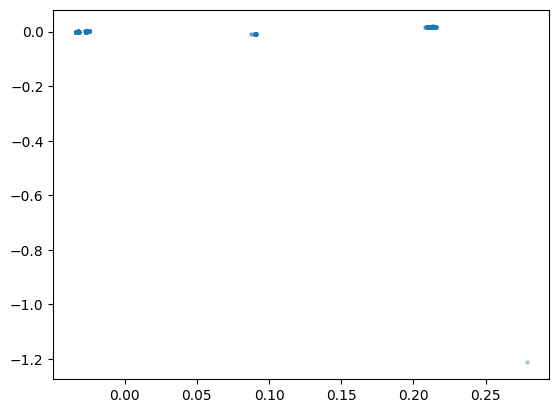

In [ ]:
X = get_pca_out(AIG(aag_path/"behavioral_mult_7bit.aag"))
plt.scatter(X[:,0], X[:,1], s=5, alpha=0.3)

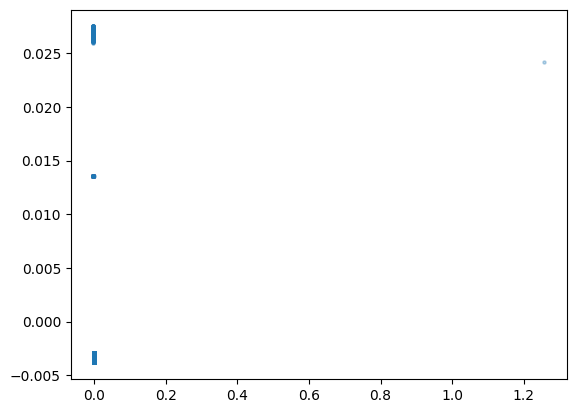

In [ ]:
X = get_pca_out(AIG(aag_path/"behavioral_mult_14bit.aag"))
plt.scatter(X[:,0], X[:,1], s=5, alpha=0.3)

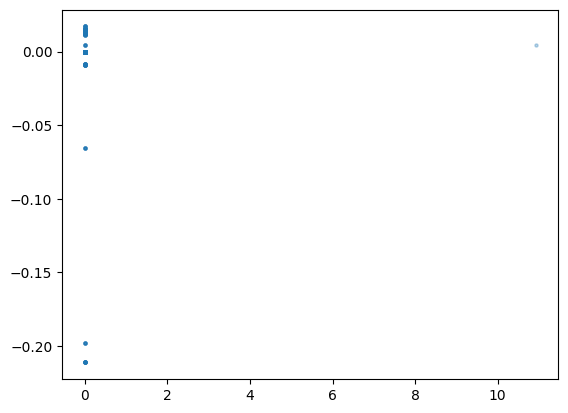

In [ ]:
X = get_pca_out(AIG(aag_path/"unrolled_mult_7bit.aag"))
plt.scatter(X[:,0], X[:,1], s=5, alpha=0.3)

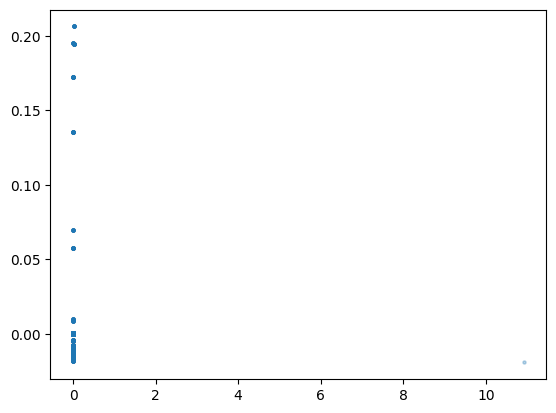

In [ ]:
X = get_pca_out(AIG(aag_path/"unrolled_mult_14bit.aag"))
plt.scatter(X[:,0], X[:,1], s=5, alpha=0.3)

In [ ]:
bn1 = nn.BatchNorm1d(128)
bn1(input_base_embed).shape

ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 128])

In [ ]:
a = {1: 2, 2: 3}
b = a.copy()

b[2] = 4

In [ ]:
a

{1: 2, 2: 3}

In [ ]:
import random

input_vals = {i: [random.randint(0, 1) for _ in range(128)] for i in range(5)}
input_vals

{0: [0,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  0,
  1,
  0,
  0,
  1,
  1,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  1,
  1,
  1,
  0,
  0,
  1,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  1,
  1,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  1,
  1,
  1,
  0,
  0,
  1,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  1,
  1,
  0,
  1,
  0,
  1,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  1,
  1,
  1,
  1,
  0,
  1,
  1,
  0,
  0,
  0,
  1,
  1,
  1,
  0,
  0,
  1,
  1],
 1: [0,
  0,
  1,
  0,
  1,
  0,
  0,
  1,
  1,
  1,
  0,
  1,
  1,
  1,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  1,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  1,
  0,
  1,
  1,
  1,
  1

In [ ]:
bool(0)

False

In [ ]:
x = torch.randn((4,2,3))
x.transpose(1, 2).shape

torch.Size([4, 3, 2])